# LightGCN — Feature-Aware with User Context
### Design mirrors BERT4Rec v2
- Same three input files: `data2.csv`, `item_features2.csv`, `user_features2.csv`
- Same item feature matrix (genre one-hots + metadata, StandardScaled)
- Same sparse-safe user feature encoder (sparsity-threshold dropout of near-zero genre cols)
- Same leave-one-out split, same HR@K / NDCG@K / MRR evaluation
- **Model**: LightGCN graph-convolution on user-item bipartite graph, enriched with content-based item embeddings and user feature fusion at scoring time


## 1. Mount Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Imports & Config

In [7]:
import os, random, math
from collections import OrderedDict

import numpy as np
import pandas as pd
import polars as pl
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


In [8]:
# ── Drive root ────────────────────────────────────────────────────────────
try:
    DRIVE_ROOT = '/content/drive/MyDrive/ML-project-1'
    print('Google Drive path set:', DRIVE_ROOT)
except Exception:
    DRIVE_ROOT = '.'

# ── File paths ────────────────────────────────────────────────────────────
INTERACTIONS_PATH  = os.path.join(DRIVE_ROOT, 'data2.csv')
ITEM_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'item_features2.csv')
USER_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'user_features2.csv')


Google Drive path set: /content/drive/MyDrive/ML-project-1


In [9]:
notebook_config = {
    'random_seed':            42,
    'model_train_flg':        True,
    'model_train_resume_flg': False,
    'model_save_path':        './lightgcn_v1.pth',
    'model_load_path':        './lightgcn_v1.pth',
}

train_config = {
    'num_epochs':          200,
    'additional_epochs':   40,
    'batch_size':          2048,    # BPR pairs per step
    'lr':                  1e-3,
    'lr_resume':           1e-4,
    'weight_decay':        1e-4,    # L2 on embeddings
    'grad_clip':           1.0,
    'neg_samples':         1,       # negatives per positive
    'min_seq_len':         3,       # filter cold-start users
}

model_config = {
    'embedding_dim':        64,     # base ID embedding size
    'num_layers':           3,      # LightGCN propagation layers
    'dropout':              0.1,
    'num_users':            0,      # filled after loading data
    'num_items':            0,      # filled after loading data
    'user_feature_dim':     0,      # filled after loading user features
}

# Reproducibility
np.random.seed(notebook_config['random_seed'])
random.seed(notebook_config['random_seed'])
torch.manual_seed(notebook_config['random_seed'])
torch.cuda.manual_seed_all(notebook_config['random_seed'])
print('Seeds set.')


Seeds set.


## 3. Data Loading & Preprocessing

In [10]:
# ── Item features ──────────────────────────────────────────────────────────
print('Loading item features...')
item_features_pd = (
    pd.read_csv(ITEM_FEATURES_PATH)
      .sort_values('item_idx')
      .reset_index(drop=True)
)
item_lookup_df = (
    item_features_pd[['item_idx', 'item_id']]
      .set_index('item_idx')
)
print(f'  Items loaded: {len(item_features_pd):,}')


Loading item features...
  Items loaded: 8,411


In [11]:
def build_item_feature_matrix(df: pd.DataFrame):
    """
    Identical to BERT4Rec v2:
      - Drops non-numeric / metadata columns
      - One-hot encodes original_language if present
      - StandardScales continuous columns, leaves binary cols intact
      - Rows 0/1 are PAD/MASK sentinel zeros; real items start at row 2
    Returns (tensor [n_items+2, feat_dim], col_names).
    """
    ignore = {'item_idx', 'item_id', 'title', 'genres_raw', 'release_date_raw'}
    num_cols = [
        c for c in df.columns
        if c not in ignore | {'original_language'}
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    if 'original_language' in df.columns:
        lang_dummies = pd.get_dummies(
            df['original_language'].fillna('unknown').astype(str), prefix='lang'
        )
    else:
        lang_dummies = pd.DataFrame(index=df.index)

    feature_df = pd.concat([df[num_cols].fillna(0), lang_dummies], axis=1).fillna(0)

    binary_cols = {c for c in feature_df.columns if feature_df[c].nunique() <= 2}
    scale_cols  = [c for c in feature_df.columns if c not in binary_cols]
    if scale_cols:
        scaler = StandardScaler()
        feature_df[scale_cols] = scaler.fit_transform(feature_df[scale_cols])

    arr    = feature_df.to_numpy(dtype=np.float32)
    padded = np.zeros((len(df) + 2, arr.shape[1]), dtype=np.float32)
    padded[2:] = arr
    return torch.tensor(padded, dtype=torch.float32), feature_df.columns.tolist()


item_feature_tensor, item_feature_columns = build_item_feature_matrix(item_features_pd)
num_items_raw = len(item_features_pd)
model_config['num_items'] = num_items_raw
print(f'Item feature matrix : {item_feature_tensor.shape}')
print(f'num_items           : {model_config["num_items"]}')


Item feature matrix : torch.Size([8413, 78])
num_items           : 8411


In [12]:
# ── User features (sparse-safe) ──────────────────────────────────────────
print('Loading user features...')
user_features_pd = (
    pd.read_csv(USER_FEATURES_PATH)
      .sort_values('user_idx')
      .reset_index(drop=True)
)


def build_user_feature_matrix(df: pd.DataFrame, sparsity_threshold: float = 0.95):
    """
    Identical to BERT4Rec v2:
      - Drops near-zero sparse columns (zero-fraction >= threshold)
      - One-hot encodes ordinal bucket columns
      - StandardScales continuous columns
    Returns (tensor [n_users, feat_dim], col_names).
    """
    drop_meta = {'user_idx', 'user_id', 'first_seen', 'last_seen'}
    ordinal   = {'user_engagement_tier', 'user_preferred_hour_bucket'}

    numeric_df  = df.drop(columns=[c for c in drop_meta if c in df.columns], errors='ignore')
    num_only    = numeric_df.select_dtypes(include='number')
    zero_frac   = (num_only == 0).mean()
    sparse_cols = zero_frac[zero_frac >= sparsity_threshold].index.tolist()
    print(f'  Dropping {len(sparse_cols)} sparse cols (zero-frac >= {sparsity_threshold})')

    keep_num = [c for c in num_only.columns
                if c not in sparse_cols and c not in ordinal]

    parts = []
    if keep_num:
        sub    = numeric_df[keep_num].fillna(0).copy()
        binary = [c for c in keep_num if sub[c].nunique() <= 2]
        cont   = [c for c in keep_num if c not in binary]
        if cont:
            scaler = StandardScaler()
            sub[cont] = scaler.fit_transform(sub[cont])
        parts.append(sub)

    for col in ordinal:
        if col in df.columns:
            dummies = pd.get_dummies(df[col].fillna(0).astype(int), prefix=col)
            parts.append(dummies)

    if not parts:
        raise ValueError('No usable user features found.')

    feature_df = pd.concat(parts, axis=1).fillna(0)
    arr = feature_df.to_numpy(dtype=np.float32)
    print(f'  User feature matrix : {arr.shape[0]:,} users x {arr.shape[1]} features')
    return torch.tensor(arr, dtype=torch.float32), feature_df.columns.tolist()


print('Building user feature matrix...')
user_feature_tensor, user_feature_columns = build_user_feature_matrix(user_features_pd)
model_config['user_feature_dim'] = user_feature_tensor.shape[1]
print(f'  user_feature_dim = {model_config["user_feature_dim"]}')


Loading user features...
Building user feature matrix...
  Dropping 9 sparse cols (zero-frac >= 0.95)
  User feature matrix : 161,619 users x 38 features
  user_feature_dim = 38


In [13]:
# ── Interactions ──────────────────────────────────────────────────────────
print('Loading interactions...')
df = pl.read_csv(INTERACTIONS_PATH)
df = df.with_columns([
    pl.col('datetime').str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False),
    pl.col('item_idx').alias('item_id_int'),    # 0-indexed, same as item_features
])
print(f'  {len(df):,} rows | {df["user_idx"].n_unique():,} users | {df["item_id_int"].n_unique():,} items')

num_users_total = len(user_features_pd)
model_config['num_users'] = num_users_total
print(f'  num_users = {num_users_total:,}')

# ── Build sorted per-user sequences (0-indexed item IDs) ─────────────────
user_rows = (
    df.group_by(['user_id', 'user_idx'])
      .agg(
          pl.col('item_id_int').sort_by(pl.col('datetime')).alias('sequence')
      )
      .sort('user_idx')
)

sequences    = user_rows['sequence'].to_list()
user_indices = user_rows['user_idx'].to_list()

# ── Leave-one-out split (same as BERT4Rec v2) ────────────────────────────
train_seqs,     val_data,  test_data     = [], [], []
train_user_idx, val_user_idx, test_user_idx = [], [], []

for seq, uidx in zip(sequences, user_indices):
    if len(seq) < train_config['min_seq_len']:
        continue
    train_seqs.append(seq[:-2]);           train_user_idx.append(uidx)
    val_data.append((seq[:-2], seq[-2]));  val_user_idx.append(uidx)
    test_data.append((seq[:-1], seq[-1])); test_user_idx.append(uidx)

print(f'  After filtering (len >= {train_config["min_seq_len"]}):')
print(f'    Train: {len(train_seqs):,}  Val: {len(val_data):,}  Test: {len(test_data):,}')


Loading interactions...
  649,250 rows | 161,619 users | 8,411 items
  num_users = 161,619
  After filtering (len >= 3):
    Train: 72,138  Val: 72,138  Test: 72,138


## 4. Graph Construction
Builds the normalised Laplacian adjacency used by LightGCN.  
Only interactions in `train_seqs` are used — no label leakage.

In [14]:
def build_norm_adj(train_sequences, user_indices, num_users, num_items, device):
    """
    Constructs the symmetric normalised adjacency matrix A_hat for LightGCN:

        A = [[0,   R  ],
             [R^T, 0  ]]

        A_hat = D^{-1/2} A D^{-1/2}

    where R is the user-item interaction matrix (train only).
    Returns a torch.sparse_coo_tensor on `device`.
    """
    rows_u, cols_i = [], []
    for seq, uidx in zip(train_sequences, user_indices):
        for iid in seq:
            rows_u.append(int(uidx))
            cols_i.append(int(iid))

    # Build R in scipy sparse
    R = sp.csr_matrix(
        (np.ones(len(rows_u), dtype=np.float32), (rows_u, cols_i)),
        shape=(num_users, num_items),
    )

    # Symmetric block adjacency A  (shape: (Nu+Ni) x (Nu+Ni))
    upper = sp.hstack([sp.csr_matrix((num_users, num_users)), R])
    lower = sp.hstack([R.T, sp.csr_matrix((num_items, num_items))])
    A     = sp.vstack([upper, lower]).tocsr()

    # D^{-1/2} diagonal
    rowsum     = np.array(A.sum(axis=1)).flatten()
    d_inv_sqrt = np.where(rowsum > 0, 1.0 / np.sqrt(rowsum), 0.0)
    D_inv_sqrt = sp.diags(d_inv_sqrt)

    A_hat = D_inv_sqrt @ A @ D_inv_sqrt
    A_hat = A_hat.tocoo()

    indices = torch.from_numpy(
        np.vstack([A_hat.row, A_hat.col]).astype(np.int64)
    )
    values = torch.from_numpy(A_hat.data.astype(np.float32))
    shape  = torch.Size([num_users + num_items, num_users + num_items])
    adj = torch.sparse_coo_tensor(indices, values, shape,
                                  dtype=torch.float32).to(device)
    return adj


print('Building normalised adjacency matrix...')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

norm_adj = build_norm_adj(
    train_seqs, train_user_idx,
    model_config['num_users'],
    model_config['num_items'],
    device,
)
print(f'Adjacency shape : {list(norm_adj.shape)}')
print(f'Non-zero entries: {norm_adj._nnz():,}')


Building normalised adjacency matrix...
Device: cuda


/tmp/ipykernel_8009/605311152.py:32: RuntimeWarning: divide by zero encountered in divide
  d_inv_sqrt = np.where(rowsum > 0, 1.0 / np.sqrt(rowsum), 0.0)


Adjacency shape : [170030, 170030]
Non-zero entries: 560,608


## 5. Model Definition

### 5.1 Item feature projector

In [15]:
class ItemFeatureProjector(nn.Module):
    """
    Projects the pre-built item feature matrix (genre one-hots + metadata)
    into the LightGCN embedding space.
    Single linear layer + LayerNorm — mirrors BertEmbedding.feature_projection
    from BERT4Rec v2.
    """
    def __init__(self, feat_dim: int, embed_dim: int):
        super().__init__()
        self.proj = nn.Linear(feat_dim, embed_dim, bias=False)
        self.norm = nn.LayerNorm(embed_dim)
        init.xavier_uniform_(self.proj.weight)

    def forward(self, feat_matrix):
        """feat_matrix: (Ni, feat_dim) -> (Ni, embed_dim)"""
        return self.norm(self.proj(feat_matrix))


### 5.2 User feature encoder

In [16]:
class UserFeatureEncoder(nn.Module):
    """
    Identical MLP + gating design to BERT4Rec v2 UserEncoder.
    Projects sparse user features -> embed_dim for scoring-time fusion.
    """
    def __init__(self, user_feat_dim: int, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1  = nn.Linear(user_feat_dim, embed_dim)
        self.fc2  = nn.Linear(embed_dim, embed_dim)
        self.gate = nn.Linear(user_feat_dim, embed_dim)  # sparse gating
        self.norm = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(dropout)
        for layer in [self.fc1, self.fc2, self.gate]:
            init.xavier_uniform_(layer.weight)
            init.zeros_(layer.bias)

    def forward(self, user_feats):
        """user_feats: (B, D_u) -> (B, embed_dim)"""
        g = torch.sigmoid(self.gate(user_feats))
        h = self.drop(F.gelu(self.fc1(user_feats)))
        h = self.drop(self.fc2(h)) * g
        return self.norm(h)


### 5.3 LightGCN core

In [17]:
class LightGCN(nn.Module):
    """
    Feature-aware LightGCN with:
      - Learnable user and item ID embeddings
      - Item content feature projection (genre, metadata) summed into item init emb
      - User feature fusion at scoring time via gated MLP
      - L-layer graph convolution with mean-pool aggregation across layers

    Scoring (user u, item i):
        score(u, i) = (E_u + UserFeat(u)) . E_i

    where E_u, E_i are layer-aggregated graph embeddings and
    UserFeat(u) is the projected user feature vector fused at inference.
    """

    def __init__(self, cfg, item_feature_matrix, user_feature_dim):
        super().__init__()
        E  = cfg['embedding_dim']
        Nu = cfg['num_users']
        Ni = cfg['num_items']

        # Learnable ID embeddings
        self.user_embedding = nn.Embedding(Nu, E)
        self.item_embedding = nn.Embedding(Ni, E)

        # Content projectors
        feat_dim = item_feature_matrix.shape[1]
        self.item_feat_proj = ItemFeatureProjector(feat_dim, E)
        self.user_feat_enc  = UserFeatureEncoder(user_feature_dim, E, cfg['dropout'])

        # Item feature matrix: store real items only (rows 2+ from the padded matrix)
        self.register_buffer('item_feat_matrix', item_feature_matrix[2:])  # (Ni, feat_dim)

        self.num_layers = cfg['num_layers']
        self.drop       = nn.Dropout(cfg['dropout'])
        self._init_weights()

    def _init_weights(self):
        init.xavier_uniform_(self.user_embedding.weight)
        init.xavier_uniform_(self.item_embedding.weight)

    # ── Graph propagation ─────────────────────────────────────────────────
    def propagate(self, norm_adj):
        """
        LightGCN propagation:
          E^(0)  = concat(E_user, E_item + ContentFeat(item))
          E^(k)  = A_hat @ E^(k-1)
          E_final = mean over all layers 0..K
        Returns user_emb (Nu, E), item_emb (Ni, E).
        """
        item_content = self.item_feat_proj(self.item_feat_matrix)  # (Ni, E)
        E0_item = self.item_embedding.weight + item_content         # (Ni, E)
        E0_user = self.user_embedding.weight                        # (Nu, E)

        all_emb    = torch.cat([E0_user, E0_item], dim=0)          # (Nu+Ni, E)
        layer_embs = [all_emb]

        for _ in range(self.num_layers):
            all_emb = torch.sparse.mm(norm_adj, all_emb)           # (Nu+Ni, E)
            layer_embs.append(all_emb)

        final_emb = torch.stack(layer_embs, dim=1).mean(dim=1)     # (Nu+Ni, E)
        Nu = self.user_embedding.num_embeddings
        return final_emb[:Nu], final_emb[Nu:]                      # (Nu,E), (Ni,E)

    # ── BPR loss for training ─────────────────────────────────────────────
    def forward(self, norm_adj, user_ids, pos_item_ids, neg_item_ids, user_feats):
        """
        BPR loss: -mean log sigma(score_pos - score_neg)
        user_feats: (B, D_u) fused into user representation.
        """
        user_emb_all, item_emb_all = self.propagate(norm_adj)

        u_emb   = user_emb_all[user_ids]      # (B, E)
        pos_emb = item_emb_all[pos_item_ids]  # (B, E)
        neg_emb = item_emb_all[neg_item_ids]  # (B, E)

        # Fuse user features
        u_feat  = self.user_feat_enc(user_feats)   # (B, E)
        u_final = u_emb + u_feat                   # (B, E)

        pos_scores = (u_final * pos_emb).sum(dim=1)  # (B,)
        neg_scores = (u_final * neg_emb).sum(dim=1)  # (B,)

        bpr_loss = -F.logsigmoid(pos_scores - neg_scores).mean()

        # L2 regularisation (on ID embeddings, not feature projectors)
        l2_reg = (
            u_emb.norm(2).pow(2) +
            pos_emb.norm(2).pow(2) +
            neg_emb.norm(2).pow(2)
        ) / user_ids.shape[0]

        return bpr_loss + train_config['weight_decay'] * l2_reg

    # ── Scoring all items for one user (inference) ────────────────────────
    @torch.no_grad()
    def score_user(self, norm_adj, user_id: int, user_feat_vec):
        """
        Returns dot-product scores for ALL items for one user.
        user_feat_vec: (D_u,) or (1, D_u)
        """
        user_emb_all, item_emb_all = self.propagate(norm_adj)
        u_emb = user_emb_all[user_id].unsqueeze(0)                 # (1, E)
        if user_feat_vec.dim() == 1:
            user_feat_vec = user_feat_vec.unsqueeze(0)
        u_feat  = self.user_feat_enc(user_feat_vec)                # (1, E)
        u_final = u_emb + u_feat                                   # (1, E)
        return (u_final @ item_emb_all.T).squeeze(0)               # (Ni,)


## 6. BPR Dataset & DataLoader
Samples (user, positive item, negative item) triplets from training sequences.

In [18]:
class BPRDataset(Dataset):
    """
    For each user, randomly samples one positive item from their history
    and one negative item (uniform over all items not in their history).
    """
    def __init__(self, sequences, user_indices, user_feature_tensor,
                 num_items, neg_samples=1):
        self.sequences           = sequences
        self.user_indices        = user_indices
        self.user_feature_tensor = user_feature_tensor
        self.num_items           = num_items
        self.neg_samples         = neg_samples
        # pre-compute positive sets for fast negative rejection sampling
        self.user_pos_sets = [set(int(x) for x in seq) for seq in sequences]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq      = self.sequences[idx]
        uidx     = int(self.user_indices[idx])
        pos_item = int(random.choice(seq))

        # Rejection-sample a true negative
        neg_item = random.randint(0, self.num_items - 1)
        while neg_item in self.user_pos_sets[idx]:
            neg_item = random.randint(0, self.num_items - 1)

        user_feat = self.user_feature_tensor[uidx]
        return (
            torch.tensor(uidx,     dtype=torch.long),
            torch.tensor(pos_item, dtype=torch.long),
            torch.tensor(neg_item, dtype=torch.long),
            user_feat,
        )


train_dataset = BPRDataset(
    train_seqs, train_user_idx, user_feature_tensor,
    model_config['num_items'],
    neg_samples=train_config['neg_samples'],
)
train_loader = DataLoader(
    train_dataset,
    batch_size=train_config['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
print(f'BPR train loader: {len(train_loader)} batches/epoch')


BPR train loader: 36 batches/epoch


## 7. Training

### 7.1 Model & optimiser setup

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = LightGCN(
    model_config,
    item_feature_tensor,
    model_config['user_feature_dim'],
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

optimizer = optim.Adam(
    model.parameters(),
    lr=train_config['lr'],
)

# Cosine annealing — same schedule family as BERT4Rec v2
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=1, eta_min=1e-5
)

start_epoch        = 0
batch_loss_history = []
epoch_loss_history = []


Device: cuda
Trainable parameters: 10,896,320


### 7.2 Training loop

Training for 200 epochs.
  Epoch 1/200 | Batch 0/36 | Loss 1.2601 | LR 1.00e-03
Epoch 1 done. Avg BPR loss: 0.3204
  Epoch 2/200 | Batch 0/36 | Loss 0.1394 | LR 9.99e-04
Epoch 2 done. Avg BPR loss: 0.1287
  Epoch 3/200 | Batch 0/36 | Loss 0.1259 | LR 9.96e-04
Epoch 3 done. Avg BPR loss: 0.1058
  Epoch 4/200 | Batch 0/36 | Loss 0.1073 | LR 9.91e-04
Epoch 4 done. Avg BPR loss: 0.0926
  Epoch 5/200 | Batch 0/36 | Loss 0.0824 | LR 9.84e-04
Epoch 5 done. Avg BPR loss: 0.0845
  Epoch 6/200 | Batch 0/36 | Loss 0.0901 | LR 9.76e-04
Epoch 6 done. Avg BPR loss: 0.0818
  Epoch 7/200 | Batch 0/36 | Loss 0.0720 | LR 9.65e-04
Epoch 7 done. Avg BPR loss: 0.0754
  Epoch 8/200 | Batch 0/36 | Loss 0.0758 | LR 9.53e-04
Epoch 8 done. Avg BPR loss: 0.0715
  Epoch 9/200 | Batch 0/36 | Loss 0.0751 | LR 9.39e-04
Epoch 9 done. Avg BPR loss: 0.0678
  Epoch 10/200 | Batch 0/36 | Loss 0.0642 | LR 9.23e-04
Epoch 10 done. Avg BPR loss: 0.0663
  Epoch 11/200 | Batch 0/36 | Loss 0.0613 | LR 9.05e-04
Epoch 11 done. Av

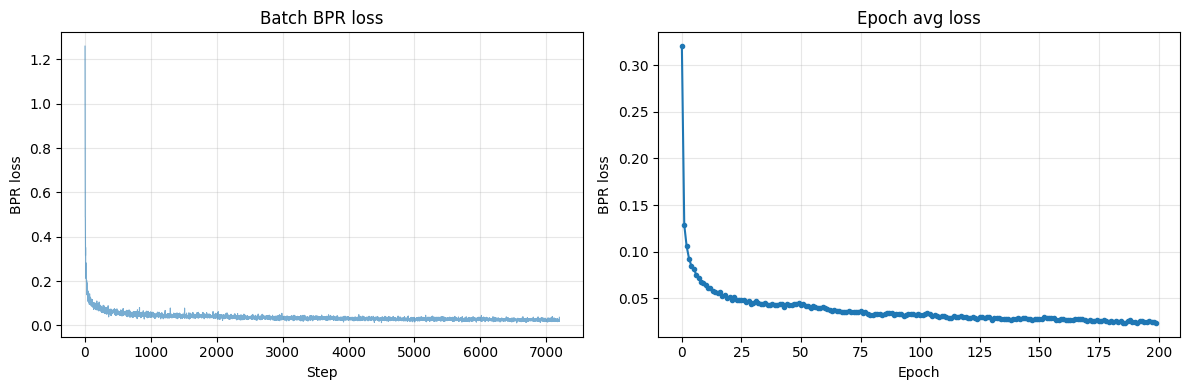

Loss curve saved to training_loss_lgcn.png


In [20]:
if notebook_config['model_train_flg']:

    # ── Optional checkpoint resume ────────────────────────────────────────
    if (notebook_config['model_train_resume_flg']
            and os.path.exists(notebook_config['model_load_path'])):
        ckpt = torch.load(notebook_config['model_load_path'], map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(device)
        start_epoch = ckpt['epoch'] + 1
        num_epochs  = start_epoch + train_config['additional_epochs']
        for g in optimizer.param_groups:
            g['lr'] = train_config['lr_resume']
        print(f'Resuming from epoch {start_epoch}')
    else:
        num_epochs = train_config['num_epochs']
        print(f'Training for {num_epochs} epochs.')

    # ── Main training loop ────────────────────────────────────────────────
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0.0

        for i, (u_ids, pos_ids, neg_ids, usr_feats) in enumerate(train_loader):
            u_ids     = u_ids.to(device)
            pos_ids   = pos_ids.to(device)
            neg_ids   = neg_ids.to(device)
            usr_feats = usr_feats.to(device)

            loss = model(norm_adj, u_ids, pos_ids, neg_ids, usr_feats)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),
                                            train_config['grad_clip'])
            optimizer.step()

            batch_loss_history.append(loss.item())
            epoch_loss += loss.item()

            if i % 100 == 0:
                print(f'  Epoch {epoch+1}/{num_epochs} | '
                      f'Batch {i}/{len(train_loader)} | '
                      f'Loss {loss.item():.4f} | '
                      f'LR {scheduler.get_last_lr()[0]:.2e}')

        scheduler.step()
        avg = epoch_loss / len(train_loader)
        epoch_loss_history.append(avg)
        print(f'Epoch {epoch+1} done. Avg BPR loss: {avg:.4f}')

        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss':                 avg,
        }, notebook_config['model_save_path'])

    # ── Loss curves ───────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(batch_loss_history, alpha=0.6, linewidth=0.8)
    ax1.set(title='Batch BPR loss', xlabel='Step', ylabel='BPR loss')
    ax1.grid(True, alpha=0.3)
    ax2.plot(epoch_loss_history, marker='o', markersize=3)
    ax2.set(title='Epoch avg loss', xlabel='Epoch', ylabel='BPR loss')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_loss_lgcn.png', dpi=120)
    plt.show()
    print('Loss curve saved to training_loss_lgcn.png')

else:
    print(f'Loading from {notebook_config["model_load_path"]}')
    ckpt = torch.load(notebook_config['model_load_path'], map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print('Pre-trained model loaded.')


## 8. Evaluation — HR@K, NDCG@K, MRR
Identical full-ranking, leave-one-out protocol to BERT4Rec v2.

In [21]:
def evaluate_all_k(model, norm_adj, eval_data, user_indices,
                   user_feature_tensor, device, k_list=(5, 10, 20)):
    """
    For each (history, target) pair:
      - Score all items with model.score_user()
      - Mask items in history
      - Rank descending, compute HR@k, NDCG@k, and MRR
    Mirrors evaluate_all_k in BERT4Rec v2 exactly.
    """
    model.eval()
    hits  = {k: [] for k in k_list}
    ndcgs = {k: [] for k in k_list}
    rr    = []

    with torch.no_grad():
        for (history, target), uidx in zip(eval_data, user_indices):
            user_feat = user_feature_tensor[int(uidx)].to(device)
            scores    = model.score_user(norm_adj, int(uidx), user_feat)  # (Ni,)

            # Mask history
            for iid in history:
                if 0 <= int(iid) < scores.shape[0]:
                    scores[int(iid)] = -1e9

            ranked = torch.argsort(scores, descending=True).tolist()

            # MRR
            if int(target) in ranked:
                rr.append(1.0 / (ranked.index(int(target)) + 1))
            else:
                rr.append(0.0)

            for k in k_list:
                if int(target) in ranked[:k]:
                    rank = ranked.index(int(target)) + 1
                    hits[k].append(1.0)
                    ndcgs[k].append(1.0 / math.log2(rank + 1))
                else:
                    hits[k].append(0.0)
                    ndcgs[k].append(0.0)

    results = {
        k: {f'HR@{k}':   round(float(np.mean(hits[k])),  4),
            f'NDCG@{k}': round(float(np.mean(ndcgs[k])), 4)}
        for k in k_list
    }
    results['MRR'] = {'MRR': round(float(np.mean(rr)), 4)}
    return results


In [22]:
print('Validation')
val_metrics = evaluate_all_k(
    model, norm_adj, val_data, val_user_idx,
    user_feature_tensor, device)
for k, m in val_metrics.items():
    print(f'  {m}')

print('\nTest')
test_metrics = evaluate_all_k(
    model, norm_adj, test_data, test_user_idx,
    user_feature_tensor, device)
for k, m in test_metrics.items():
    print(f'  {m}')


Validation
  {'HR@5': 0.1233, 'NDCG@5': 0.0879}
  {'HR@10': 0.17, 'NDCG@10': 0.103}
  {'HR@20': 0.228, 'NDCG@20': 0.1176}
  {'MRR': 0.0917}

Test
  {'HR@5': 0.0809, 'NDCG@5': 0.055}
  {'HR@10': 0.1204, 'NDCG@10': 0.0677}
  {'HR@20': 0.1754, 'NDCG@20': 0.0815}
  {'MRR': 0.0609}


## 9. Inference & Recommendation

In [23]:
def get_item_name(item_idx_0based: int, item_lookup_df: pd.DataFrame) -> str:
    """item_idx_0based is the raw 0-based index from item_features2.csv."""
    if item_idx_0based < 0:
        return f'<special {item_idx_0based}>'
    return (
        item_lookup_df.loc[item_idx_0based, 'item_id']
        if item_idx_0based in item_lookup_df.index
        else f'unk_{item_idx_0based}'
    )


def recommend(history, user_idx, model, norm_adj, item_lookup_df,
              user_feature_tensor, device, k=10, exclude_history=True):
    """
    Returns top-k item recommendations for a user.
    history : list of 0-based item indices
    user_idx: integer user index from user_features2.csv
    """
    model.eval()
    user_feat    = user_feature_tensor[int(user_idx)].to(device)
    scores_full  = model.score_user(norm_adj, int(user_idx), user_feat).clone()

    if exclude_history:
        for iid in history:
            if 0 <= int(iid) < scores_full.shape[0]:
                scores_full[int(iid)] = -1e9

    probs        = torch.softmax(scores_full, dim=0)
    top_v, top_i = torch.topk(probs, k=k)

    topk = OrderedDict(
        (get_item_name(i.item(), item_lookup_df), round(p.item(), 6))
        for i, p in zip(top_i, top_v)
    )
    sampled_i = torch.multinomial(probs, num_samples=k, replacement=False)
    sampled   = OrderedDict(
        (get_item_name(i.item(), item_lookup_df), round(probs[i].item(), 6))
        for i in sampled_i
    )
    return {'topk': topk, 'sampled': sampled, 'probs': probs}


In [24]:
# Demo
sample_history, sample_target = val_data[0]
sample_uidx = val_user_idx[0]

print(f'User idx          : {sample_uidx}')
print(f'History length    : {len(sample_history)} items')
print(f'True next item    : {get_item_name(int(sample_target), item_lookup_df)}')

results = recommend(
    sample_history, sample_uidx, model, norm_adj,
    item_lookup_df, user_feature_tensor, device, k=10,
)

true_name = get_item_name(int(sample_target), item_lookup_df)
print('\nTop-10 (deterministic):')
for name, p in results['topk'].items():
    marker = ' <- TRUE' if name == true_name else ''
    print(f'  {name:<30}  p={p:.6f}{marker}')

print('\nTop-10 (sampled):')
for name, p in results['sampled'].items():
    print(f'  {name:<30}  p={p:.6f}')


User idx          : 1
History length    : 22 items
True next item    : d601124c11

Top-10 (deterministic):
  1be30c77ef                      p=0.088388
  0ca8bc0382                      p=0.033975
  0fc283bc6d                      p=0.033558
  a8df8dd2f3                      p=0.029885
  f5f284408b                      p=0.023399
  510b52ee06                      p=0.021006
  1d395fe402                      p=0.020157
  05d1474c9e                      p=0.018884
  13e9f8fac8                      p=0.015711
  881e4cdac3                      p=0.015414

Top-10 (sampled):
  72442b8f9a                      p=0.000226
  a8df8dd2f3                      p=0.029885
  f5f284408b                      p=0.023399
  893b098d8e                      p=0.004781
  a45280bebd                      p=0.001854
  05d1474c9e                      p=0.018884
  49f5198421                      p=0.000889
  7c039293d4                      p=0.003686
  ae5b8067a5                      p=0.010800
  080f74d403       

## 10. Item-Embedding Similarity
Uses the graph-propagated + content-enriched item embeddings.

In [25]:
def get_similar_items(query_item_idx: int, model, norm_adj,
                      item_lookup_df: pd.DataFrame, device, k=10):
    """
    Finds k most similar items by cosine similarity in the
    graph-propagated + content-enriched embedding space.
    query_item_idx: 0-based item index from item_features2.csv.
    """
    model.eval()
    with torch.no_grad():
        _, item_emb_all = model.propagate(norm_adj)  # (Ni, E)
        item_emb_all    = item_emb_all.cpu()

    q    = item_emb_all[query_item_idx]               # (E,)
    sims = F.cosine_similarity(q.unsqueeze(0), item_emb_all, dim=1)
    top_sims, top_idx = torch.topk(sims, k + 1)

    results = []
    for idx, score in zip(top_idx.tolist(), top_sims.tolist()):
        if idx == query_item_idx:
            continue
        results.append((get_item_name(idx, item_lookup_df), round(score, 4)))
        if len(results) == k:
            break

    return {
        'query':         get_item_name(query_item_idx, item_lookup_df),
        'similar_items': results,
    }


query_iid   = int(val_data[0][0][0])
sim_results = get_similar_items(query_iid, model, norm_adj, item_lookup_df, device)
print(f'Similar to: {sim_results["query"]}')
for name, score in sim_results['similar_items']:
    print(f'  {name:<30}  cos_sim={score:.4f}')

print('\n✓ LightGCN pipeline complete.')


Similar to: 7314699c23
  d2b25e1c92                      cos_sim=0.9344
  9d046162e5                      cos_sim=0.9256
  7b30d019ba                      cos_sim=0.9192
  07a6fde120                      cos_sim=0.9157
  bb1b21a139                      cos_sim=0.9040
  720d4b99ea                      cos_sim=0.8850
  46e1a59624                      cos_sim=0.8837
  0fa2d624f1                      cos_sim=0.8824
  483817e9f5                      cos_sim=0.8811
  f7eac74c8c                      cos_sim=0.8802

✓ LightGCN pipeline complete.
